<div style="text-align:center; margin-top:45px;">

<img src="img/logoitqv1.jpg" width="600">

<h1 style="
font-family:'Times New Roman', serif;
font-size:42px;
font-weight:bold;
margin-top:30px;
margin-bottom:20px;
">

Evaluacion Primer Parcial

</h1>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
margin-top:15px;
">

September 30, 2026

</p>

<p style="
font-family:'Times New Roman', serif;
font-size:20px;
margin-top:45px;
margin-bottom:8px;
">

Inetgrantes:  

Kevin Xavier Suasnavas Villarreal

Kevin Alberto Yalama Bastidas

</p>

<p style="
font-family:'Times New Roman', serif;
font-size:18px;
margin-top:5px;
">

<a href="https://github.com/kevinsuas433/Machine2026.git">
<strong>Link a mi GitHub</strong>
</a>

https://github.com/kevinsuas433/Machine2026.git

</p>

</div>

---

# EVALUACION

# REGRESIÓN LINEAL MÚLTIPLE — GASTOS MÉDICOS

## Actividad Práctico Experimental

El objetivo de esta práctica es desarrollar un proceso completo de Machine Learning
para construir un modelo de Regresión Lineal Múltiple capaz de estimar los gastos
médicos a partir de las características disponibles en el conjunto de datos.

Se aplicarán las etapas de análisis exploratorio, tratamiento de datos, detección de
valores atípicos, transformación de variables, selección de atributos, validación,
entrenamiento, evaluación y predicción de nuevas observaciones.

# Descripción de la actividad: 
Una organización relacionada con servicios de salud desea analizar qué características de sus registros están asociadas con los costos médicos y construir un modelo que permita estimar el valor de charges para nuevas observaciones.
El dataset proporciona edad, sexo, índice de masa corporal (BMI), número de dependientes, condición de fumador, región y gastos médicos.
El estudiante deberá desarrollar un notebook que resuelva las siguientes etapas.
El conjunto de dato se desde kaggle debe ser automatizado la descarga desde el mismo lenguaje


# Recursos necesarios
1.	Conjunto de datos descargados desde kaggle insurance.csv https://www.kaggle.com/datasets/mirichoi0218/insurance
2.	Ananconda
3.	Generar el pipelin detallada de cada una de las fases dlproyecto 


# Desarrollo: 
1.	Carga y comprensión de los datos — 10 %
2.	EDA y calidad de los datos — 15 %
3.	Detección de outliers — 10 %
4.	Preparación de variables — 10 %
5.	Normalización o estandarización — 10 %
6.	Selección de atributos — 10 %
7.	Validación de datos — 10 %
8.	Entrenamiento mediante Regresión Lineal — 10 %
9.	Evaluación — 10 %
10.	Predicción con nuevos datos — 5 %


# 1. Carga y comprensión de los datos

En esta primera etapa se realiza la carga y comprensión del conjunto de datos
`insurance.csv`. El objetivo es conocer cómo está estructurada la información
antes de comenzar con el análisis y la construcción del modelo de Machine Learning.

El conjunto de datos contiene información relacionada con personas y sus gastos
médicos. Entre las variables disponibles se encuentran la edad, sexo, índice de
masa corporal (BMI), número de hijos o dependientes, condición de fumador,
región y los gastos médicos (`charges`).

La variable `charges` será utilizada posteriormente como variable objetivo,
ya que es el valor que se desea estimar mediante el modelo de Regresión Lineal
Múltiple.

# Importación de librerías

En esta sección se importan las librerías necesarias para realizar el análisis,
procesamiento, entrenamiento y evaluación del modelo de Machine Learning.

In [10]:
%pip install -q kaggle pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [11]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# Librerías para manejo del sistema y archivos
import os
import glob

# Librerías para manejo de datos
import numpy as np
import pandas as pd

# Librería para visualización
import matplotlib.pyplot as plt

# Librerías de Machine Learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.feature_selection import (
    SelectKBest,
    f_regression
)

from sklearn.linear_model import LinearRegression

from sklearn import metrics

# Librería para advertencias
import warnings

warnings.filterwarnings("ignore")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1.2 Descarga del conjunto de datos

Para obtener los datos se utiliza el conjunto `insurance.csv` disponible en
Kaggle. La descarga se realiza directamente desde Python para automatizar
el proceso y evitar tener que descargar manualmente el archivo.

De esta manera, el notebook puede realizar la descarga y posteriormente
localizar el archivo para cargarlo mediante pandas.

## 1.3 Configuración de Kaggle

Para descargar el conjunto de datos desde Kaggle se utiliza la API
oficial de Kaggle.

La API utiliza un archivo denominado `kaggle.json`, el cual contiene
las credenciales de acceso del usuario.

In [44]:
# ==========================================================
# CONFIGURACIÓN DE KAGGLE
# ==========================================================
#
# Se define manualmente la ubicación del archivo kaggle.json
# dentro de nuestro proyecto.
#
# ==========================================================

import os

# ----------------------------------------------------------
# 1. Ruta de la carpeta .kaggle
# ----------------------------------------------------------

carpeta_kaggle = r"C:\Users\Kevin\Desktop\machine\practicas\.kaggle"

# ----------------------------------------------------------
# 2. Ruta completa del archivo de credenciales
# ----------------------------------------------------------

ruta_kaggle = os.path.join(
    carpeta_kaggle,
    "kaggle.json"
)

# ----------------------------------------------------------
# 3. Mostrar las rutas utilizadas
# ----------------------------------------------------------

print("Carpeta de Kaggle:")
print(carpeta_kaggle)

print("\nArchivo de credenciales:")
print(ruta_kaggle)

# ----------------------------------------------------------
# 4. Verificar que exista kaggle.json
# ----------------------------------------------------------

if os.path.isfile(ruta_kaggle):
    print("\n✓ kaggle.json encontrado correctamente.")
else:
    print("\n✗ kaggle.json NO encontrado.")
    print("\nRevisa que el archivo se encuentre exactamente en:")
    print(ruta_kaggle)

Carpeta de Kaggle:
C:\Users\Kevin\Desktop\machine\practicas\.kaggle

Archivo de credenciales:
C:\Users\Kevin\Desktop\machine\practicas\.kaggle\kaggle.json

✓ kaggle.json encontrado correctamente.


### 1.3 Carga del dataset

Una vez descargado el conjunto de datos, se utiliza la biblioteca pandas
para leer el archivo `insurance.csv` y almacenarlo en un DataFrame.

El DataFrame permite trabajar con los datos de forma organizada y facilita
las siguientes etapas del proyecto, como el análisis exploratorio,
la preparación de las variables y el entrenamiento del modelo.

In [20]:
# ==========================================================
# CARGA DEL CONJUNTO DE DATOS
# ==========================================================
#
# El archivo insurance.csv ya fue descargado previamente
# y se encuentra dentro de la carpeta "dataset".
#
# Por esta razón, no volveremos a descargarlo desde Kaggle.
# ==========================================================

import os
import pandas as pd

# ----------------------------------------------------------
# Definir la ruta de la carpeta donde está el dataset
# ----------------------------------------------------------

carpeta_dataset = r"C:\Users\Kevin\Desktop\machine\practicas\dataset"

# ----------------------------------------------------------
# Definir la ruta completa del archivo CSV
# ----------------------------------------------------------

ruta_dataset = os.path.join(
    carpeta_dataset,
    "insurance.csv"
)

print("Ruta del dataset:")
print(ruta_dataset)

# ----------------------------------------------------------
# Verificar que el archivo exista
# ----------------------------------------------------------

if os.path.isfile(ruta_dataset):
    print("\n✓ insurance.csv encontrado correctamente.")
else:
    print("\n✗ No se encontró insurance.csv.")
    print("\nContenido de la carpeta dataset:")
    
    if os.path.exists(carpeta_dataset):
        for archivo in os.listdir(carpeta_dataset):
            print(" -", archivo)
    else:
        print("La carpeta dataset tampoco existe.")

Ruta del dataset:
C:\Users\Kevin\Desktop\machine\practicas\dataset\insurance.csv

✓ insurance.csv encontrado correctamente.


### 1.4 Dimensiones del dataset

Para comprender el tamaño del conjunto de datos se obtiene el número de
filas y columnas. Esto permite conocer cuántas observaciones están disponibles
y cuántas variables contiene el dataset.

In [21]:
# ==========================================================
# LECTURA DEL ARCHIVO CSV
# ==========================================================
#
# Se utiliza pandas para cargar el conjunto de datos
# en un DataFrame.
# ==========================================================

df = pd.read_csv(ruta_dataset)

print("✓ Dataset cargado correctamente.")
print(f"\nNúmero de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

✓ Dataset cargado correctamente.

Número de filas: 1338
Número de columnas: 7


In [22]:
# ==========================================================
# VISUALIZACIÓN INICIAL
# ==========================================================
#
# Mostramos los primeros registros para conocer la estructura
# y el tipo de información disponible.
# ==========================================================

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
# ==========================================================
# INFORMACIÓN GENERAL DEL DATASET
# ==========================================================
#
# Esta sección permite identificar:
# - Número de registros
# - Columnas
# - Tipos de datos
# - Valores no nulos
# - Uso de memoria
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 1.5 Estadísticas descriptivas

Finalmente, se obtienen las estadísticas descriptivas de las variables
numéricas. Esto permite conocer valores como el promedio, desviación estándar,
mínimo, máximo y cuartiles.

Esta información ayuda a tener una primera idea del comportamiento de los
datos antes de realizar el análisis exploratorio.

In [24]:
# ==========================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ==========================================================
#
# Se calculan medidas estadísticas de las variables
# numéricas del conjunto de datos.
#
# Entre ellas:
# - Cantidad
# - Media
# - Desviación estándar
# - Mínimo
# - Cuartiles
# - Máximo
# ==========================================================

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# 2. EDA y calidad de los datos

En esta etapa se realiza el Análisis Exploratorio de Datos (EDA) con el
objetivo de conocer mejor el comportamiento del conjunto de datos antes
de realizar la preparación y entrenamiento del modelo.

Primero se revisa la calidad de los datos, principalmente los valores
nulos, registros duplicados y tipos de datos. Después se analizan las
variables numéricas y categóricas mediante estadísticas y gráficos.

Esta etapa es importante porque permite identificar posibles problemas
en los datos y comprender qué características pueden estar relacionadas
con los gastos médicos (`charges`).

In [25]:
# ==========================================================
# ANÁLISIS DE VARIABLES CATEGÓRICAS
# ==========================================================
#
# Se identifican las variables que contienen información
# categórica y se muestran sus valores únicos.
# ==========================================================

columnas_categoricas = df.select_dtypes(
    include=["object"]
).columns

print("Variables categóricas:")
print(list(columnas_categoricas))

print("\nValores únicos por variable:")

for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(df[columna].unique())

Variables categóricas:
['sex', 'smoker', 'region']

Valores únicos por variable:

sex:
['female' 'male']

smoker:
['yes' 'no']

region:
['southwest' 'southeast' 'northwest' 'northeast']


In [26]:
# ==========================================================
# VERIFICACIÓN DE VALORES NULOS
# ==========================================================
#
# Se comprueba si existen datos faltantes en alguna
# de las variables.
# ==========================================================

valores_nulos = df.isnull().sum()

print("Valores nulos por columna:")
print(valores_nulos)

if valores_nulos.sum() == 0:
    print("\n✓ No existen valores nulos en el dataset.")
else:
    print("\n⚠ Se encontraron valores nulos.")

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

✓ No existen valores nulos en el dataset.


### 2.1 Revisión de registros duplicados

Además de revisar los valores nulos, se comprueba si existen registros
duplicados.

Los registros repetidos pueden afectar el análisis porque una misma
observación podría tener más peso durante el entrenamiento del modelo.

In [27]:
# ==========================================================
# VERIFICACIÓN DE DUPLICADOS
# ==========================================================
#
# Se identifican registros completamente repetidos.
# ==========================================================

duplicados = df.duplicated().sum()

print("Número de registros duplicados:", duplicados)

if duplicados == 0:
    print("✓ No existen registros duplicados.")
else:
    print("⚠ Existen registros duplicados.")

Número de registros duplicados: 1
⚠ Existen registros duplicados.


### 2.2 Revisión de tipos de datos

Se revisan nuevamente los tipos de datos de las variables para identificar
cuáles son numéricas y cuáles son categóricas.

Esta clasificación será importante en las siguientes etapas, ya que las
variables categóricas necesitarán una transformación antes de utilizarlas
en la Regresión Lineal Múltiple.

In [50]:
# ==========================================================
# TIPOS DE DATOS
# ==========================================================

# Reviso el tipo de dato de cada variable para identificar
# cuáles son numéricas y cuáles son categóricas.
display(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

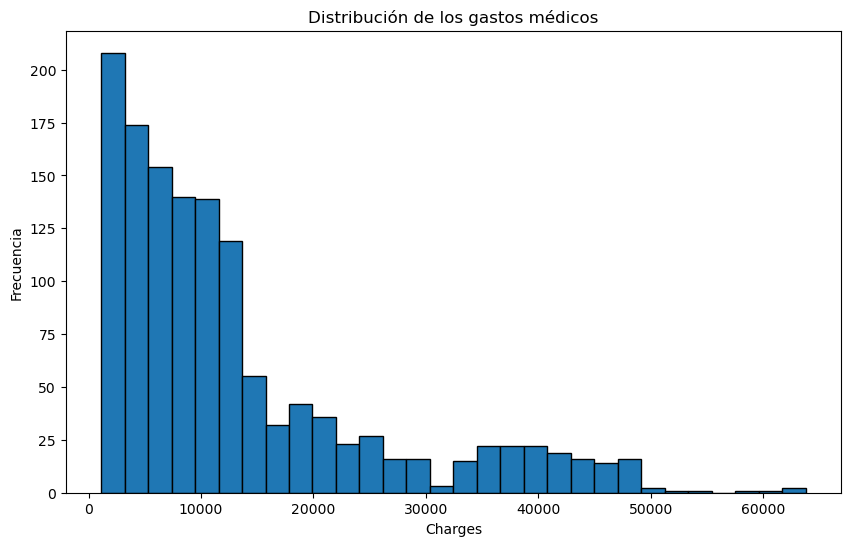

In [28]:
# ==========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================================
#
# La variable "charges" representa los gastos médicos
# que queremos predecir mediante el modelo.
#
# Se utiliza un histograma para observar su distribución.
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["charges"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de los gastos médicos")
plt.xlabel("Charges")
plt.ylabel("Frecuencia")

plt.show()

### 2.3 Análisis estadístico de las variables numéricas

Para comprender el comportamiento de las variables numéricas se utilizan
estadísticas descriptivas como la media, desviación estándar, mínimo,
máximo y cuartiles.

Esto permite tener una idea general de los valores que contiene el dataset
y detectar posibles diferencias importantes entre las variables.

### 2.4 Distribución de las variables numéricas

Se utilizan histogramas para observar cómo se distribuyen las principales
variables numéricas del dataset.

Se analizan la edad, el BMI, el número de dependientes y los gastos médicos.
Los gráficos permiten identificar la concentración de los valores y observar
la forma general de sus distribuciones.

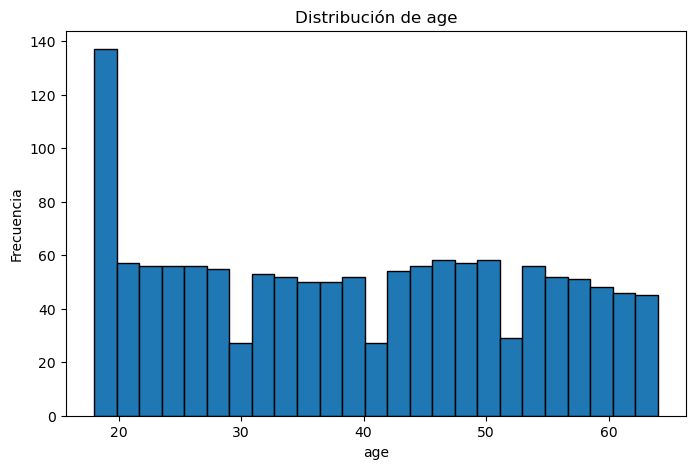

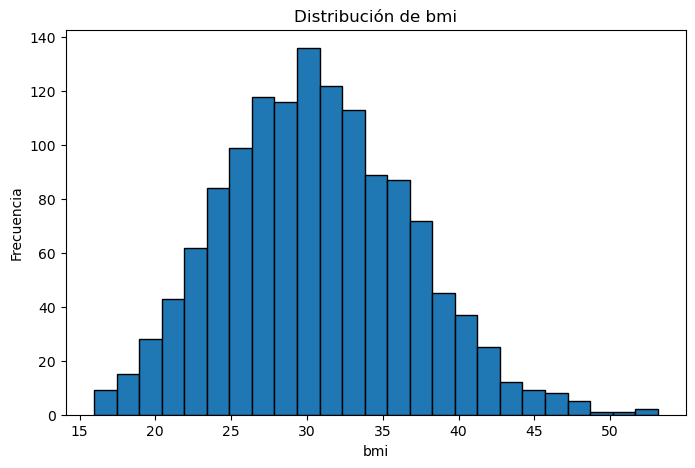

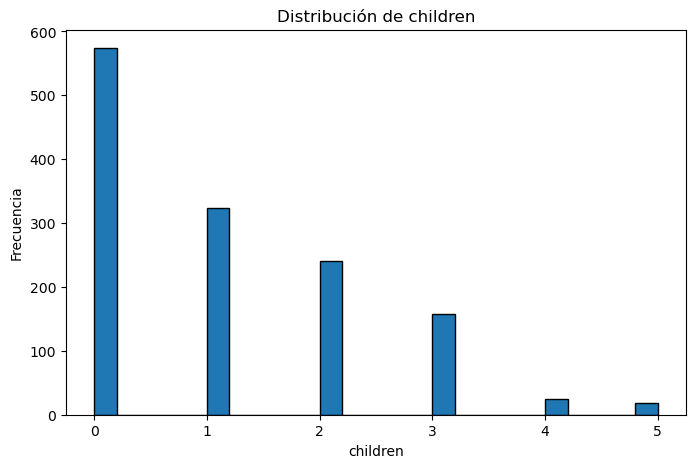

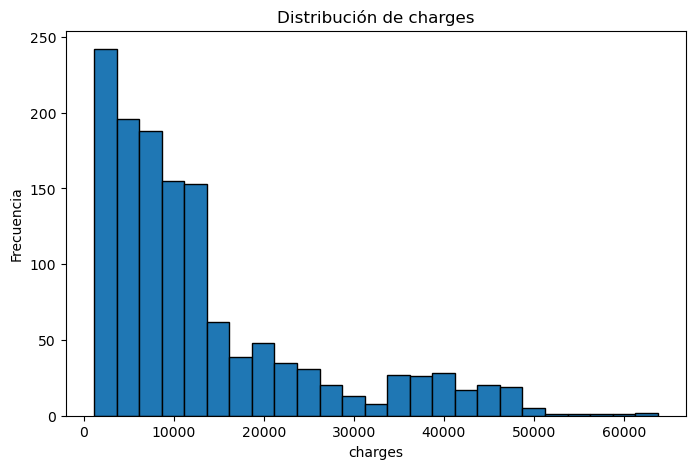

In [29]:
# ==========================================================
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ==========================================================
#
# Se generan histogramas para observar la distribución
# de las principales variables numéricas.
# ==========================================================

variables_numericas = [
    "age",
    "bmi",
    "children",
    "charges"
]

for columna in variables_numericas:
    
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        df[columna],
        bins=25,
        edgecolor="black"
    )
    
    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")
    
    plt.show()

### 2.5 Análisis de variables categóricas

También se analiza la distribución de las variables categóricas para
conocer cuántos registros pertenecen a cada categoría.

Las variables categóricas presentes en el dataset son sexo, condición
de fumador y región.

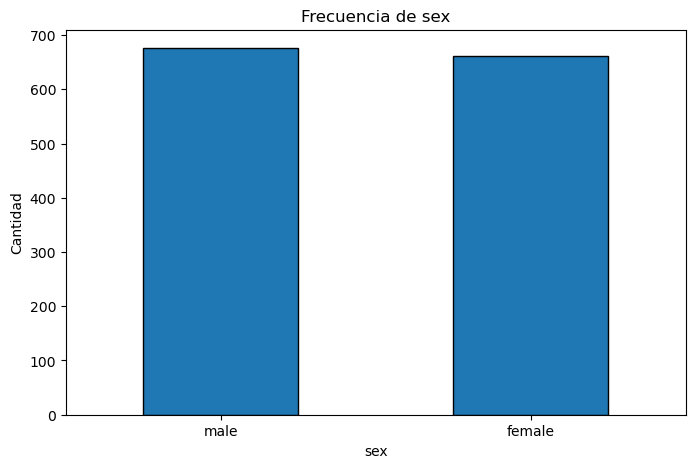

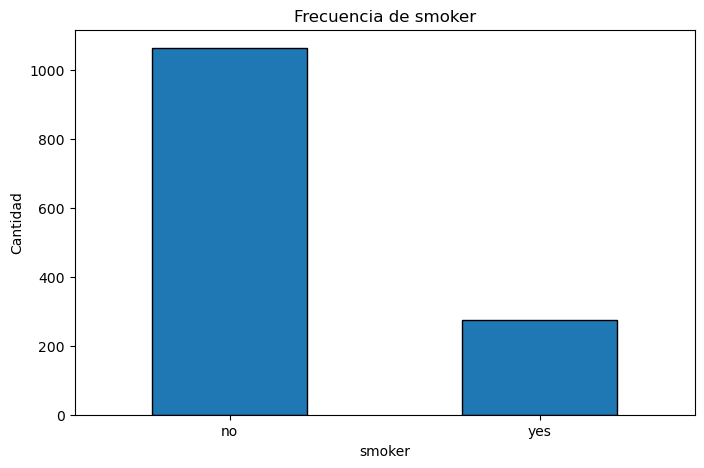

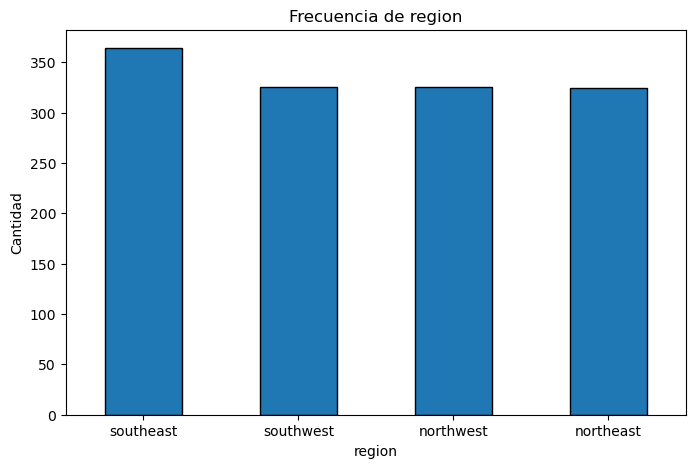

In [30]:
# ==========================================================
# ANÁLISIS DE VARIABLES CATEGÓRICAS
# ==========================================================
#
# Se muestran las frecuencias de las variables categóricas.
# ==========================================================

for columna in columnas_categoricas:
    
    plt.figure(figsize=(8, 5))
    
    df[columna].value_counts().plot(
        kind="bar",
        edgecolor="black"
    )
    
    plt.title(f"Frecuencia de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Cantidad")
    
    plt.xticks(rotation=0)
    
    plt.show()

### 2.6 Relación entre las variables y los gastos médicos

Como `charges` es la variable que se desea predecir, se analiza su relación
con algunas de las principales variables del dataset.

En esta primera exploración se comparan los gastos médicos con la edad y
el BMI. También se analiza posteriormente la condición de fumador, ya que
es una variable categórica que puede presentar diferencias en los gastos.

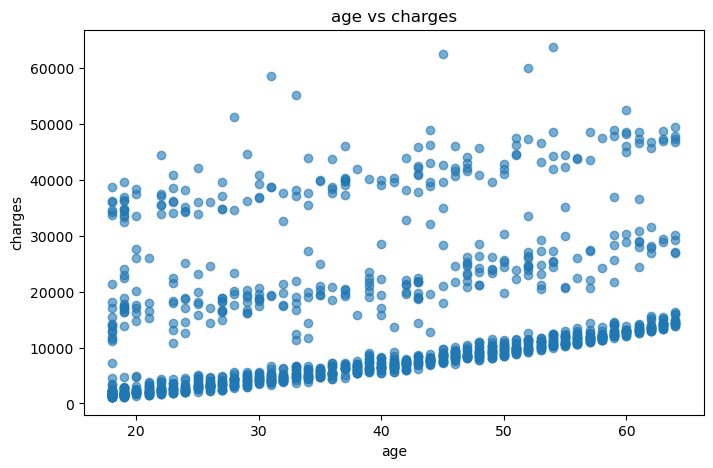

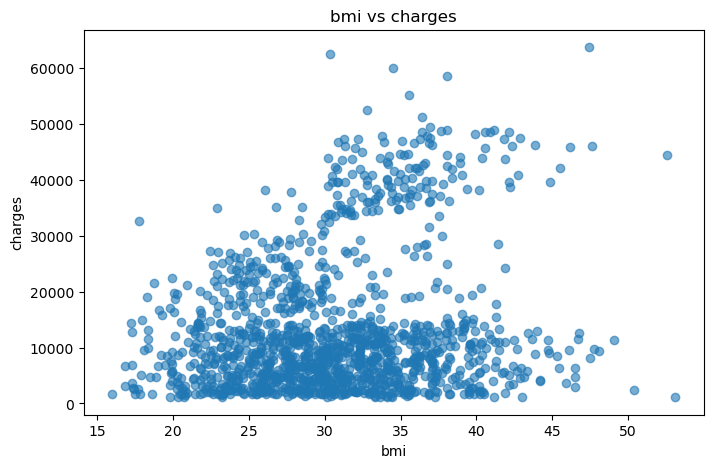

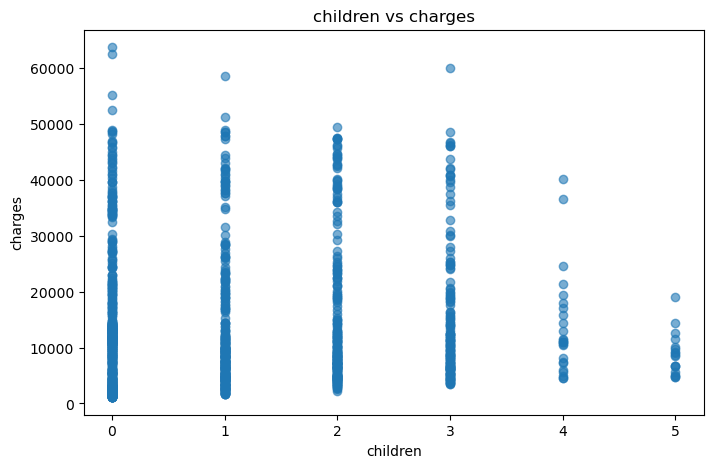

In [31]:
# ==========================================================
# RELACIÓN ENTRE VARIABLES NUMÉRICAS Y CHARGES
# ==========================================================
#
# Se utilizan diagramas de dispersión para observar
# posibles relaciones entre las variables predictoras
# numéricas y la variable objetivo.
# ==========================================================

variables_predictoras_numericas = [
    "age",
    "bmi",
    "children"
]

for columna in variables_predictoras_numericas:
    
    plt.figure(figsize=(8, 5))
    
    plt.scatter(
        df[columna],
        df["charges"],
        alpha=0.6
    )
    
    plt.title(f"{columna} vs charges")
    plt.xlabel(columna)
    plt.ylabel("charges")
    
    plt.show()

### 2.7 Matriz de correlación

Finalmente, se analiza la correlación entre las variables numéricas.

La correlación permite observar qué tan relacionada está una variable
numérica con otra. En este caso también permite observar la relación de
`charges` con variables como edad, BMI y número de dependientes.

Esta información sirve como una primera referencia para comprender los
datos antes de realizar la selección de atributos.

In [32]:
# ==========================================================
# MATRIZ DE CORRELACIÓN
# ==========================================================
#
# Se analiza la correlación entre las variables numéricas.
# Esto permite observar qué variables presentan mayor
# relación lineal con "charges".
# ==========================================================

correlacion = df[
    ["age", "bmi", "children", "charges"]
].corr()

print(correlacion)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


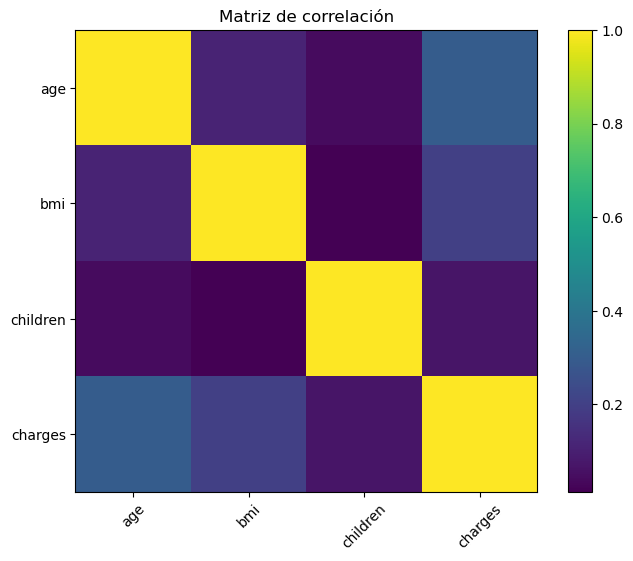

In [33]:
# ==========================================================
# VISUALIZACIÓN DE LA CORRELACIÓN
# ==========================================================
#
# Se representa gráficamente la matriz de correlación.
# ==========================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    correlacion,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title("Matriz de correlación")

plt.show()

### 2.8 Interpretación del análisis exploratorio

Después de revisar el conjunto de datos, se puede observar que las variables
numéricas presentan diferentes rangos y distribuciones. La variable `charges`
presenta una distribución amplia, por lo que los gastos médicos no tienen
todos el mismo comportamiento.

También se observa que las variables categóricas, como `smoker`, `sex` y
`region`, presentan diferentes cantidades de registros por categoría.

Al comparar `charges` con la edad y el BMI se pueden observar ciertos patrones
en los datos, aunque estas relaciones no son suficientes por sí solas para
explicar completamente los gastos médicos.

La variable `smoker` también muestra diferencias en el promedio de gastos
médicos entre sus categorías. Por esta razón, será importante incluir las
variables categóricas en el modelo después de realizar la transformación
correspondiente.

En cuanto a la calidad de los datos, la revisión de valores nulos y
duplicados permite comprobar si el dataset necesita algún tratamiento antes
de continuar con las siguientes etapas.

# 3. Detección de valores atípicos

En esta etapa se buscan valores atípicos o outliers dentro de las variables
numéricas del conjunto de datos.

Los valores atípicos son observaciones que se encuentran alejadas del
comportamiento general de los datos. Es importante identificarlos porque
pueden influir en el análisis y posteriormente en el modelo de regresión.

Para realizar esta detección se utilizará el método del rango intercuartílico
(IQR), junto con diagramas de caja (boxplots) para visualizar los posibles
valores atípicos.

### 3.1 Visualización de los valores atípicos

Además del cálculo mediante IQR, se utilizan diagramas de caja para observar
visualmente la presencia de valores atípicos.

En un boxplot, los puntos que aparecen alejados de la caja y de los límites
principales pueden representar posibles valores atípicos.

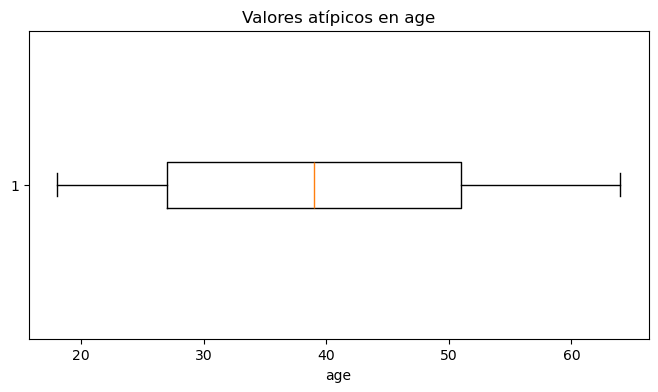

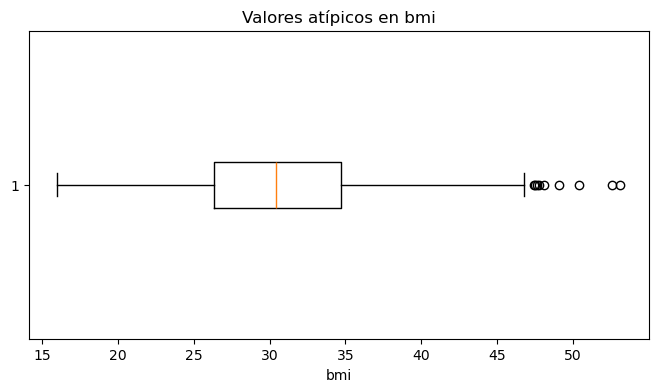

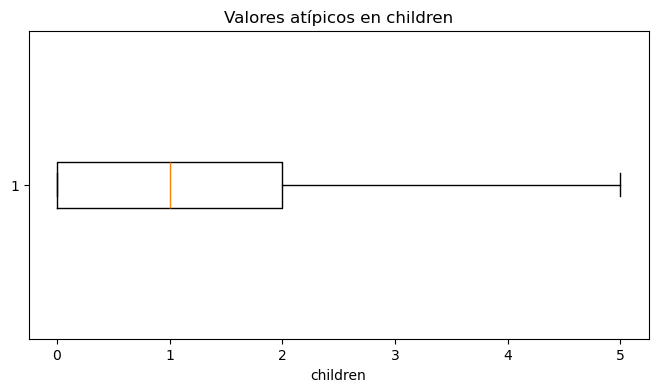

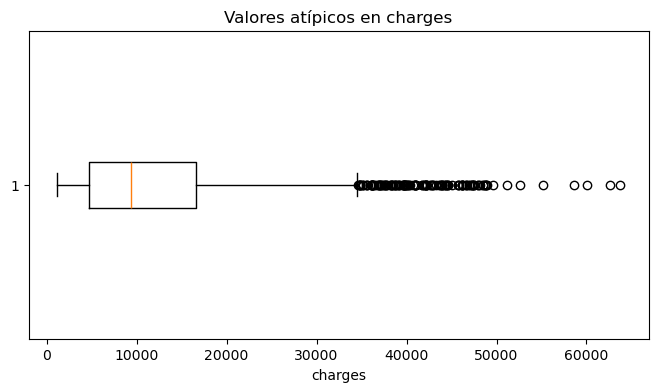

In [34]:
# ==========================================================
# DETECCIÓN DE VALORES ATÍPICOS
# ==========================================================
#
# Los diagramas de caja permiten identificar posibles
# valores atípicos en las variables numéricas.
# ==========================================================

for columna in variables_numericas:
    
    plt.figure(figsize=(8, 4))
    
    plt.boxplot(
        df[columna],
        vert=False
    )
    
    plt.title(f"Valores atípicos en {columna}")
    plt.xlabel(columna)
    
    plt.show()

### 3.2 Método del rango intercuartílico (IQR)

El rango intercuartílico se calcula como:

**IQR = Q3 - Q1**

donde:

- **Q1** corresponde al primer cuartil.
- **Q3** corresponde al tercer cuartil.
- **IQR** representa el rango donde se encuentra el 50 % central de los datos.

Para identificar posibles outliers se establecen los siguientes límites:

**Límite inferior = Q1 - 1.5 × IQR**

**Límite superior = Q3 + 1.5 × IQR**

Los valores que se encuentren fuera de estos límites serán considerados
posibles valores atípicos.

In [35]:
# ==========================================================
# DETECCIÓN DE OUTLIERS MEDIANTE IQR
# ==========================================================
#
# IQR = Q3 - Q1
#
# Se considera como posible valor atípico aquel que está:
#
# Menor que Q1 - 1.5 * IQR
# Mayor que Q3 + 1.5 * IQR
# ==========================================================

for columna in variables_numericas:
    
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]
    
    print(f"\nVariable: {columna}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Número de posibles outliers: {len(outliers)}")


Variable: age
Q1: 27.00
Q3: 51.00
IQR: 24.00
Límite inferior: -9.00
Límite superior: 87.00
Número de posibles outliers: 0

Variable: bmi
Q1: 26.30
Q3: 34.69
IQR: 8.40
Límite inferior: 13.70
Límite superior: 47.29
Número de posibles outliers: 9

Variable: children
Q1: 0.00
Q3: 2.00
IQR: 2.00
Límite inferior: -3.00
Límite superior: 5.00
Número de posibles outliers: 0

Variable: charges
Q1: 4740.29
Q3: 16639.91
IQR: 11899.63
Límite inferior: -13109.15
Límite superior: 34489.35
Número de posibles outliers: 139


### 3.3 Selección de variables numéricas

Primero se seleccionan las variables numéricas del dataset, ya que el método
IQR se aplicará sobre estas variables.

En este caso se consideran `age`, `bmi`, `children` y `charges`.

In [36]:
# ==========================================================
# SEPARACIÓN DE VARIABLES
# ==========================================================
#
# X contiene las variables independientes o predictoras.
#
# y contiene la variable dependiente que queremos predecir:
# "charges".
# ==========================================================

X = df.drop(
    columns=["charges"]
)

y = df["charges"]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print("charges")

Variables predictoras:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Variable objetivo:
charges


### 3.4 Interpretación de los valores atípicos

Después de aplicar el método IQR y observar los diagramas de caja, se
identifican posibles valores atípicos en algunas de las variables numéricas.

Sin embargo, que un valor sea identificado como outlier no significa
automáticamente que sea un dato incorrecto. En este conjunto de datos,
algunos valores alejados del promedio pueden representar situaciones
reales de los registros médicos.

Por esta razón, antes de eliminar estos valores se debe analizar si
corresponden a errores de registro o si representan casos reales.

En este proyecto se decide conservar los valores atípicos que corresponden
a observaciones válidas, ya que eliminarlos sin una justificación podría
provocar la pérdida de información importante para el modelo.

La identificación de estos valores se tendrá en cuenta en las siguientes
etapas del procesamiento y entrenamiento del modelo.

### 3.5 Conclusión de la detección de outliers

La aplicación del método IQR permitió identificar los posibles valores
atípicos presentes en las variables numéricas del dataset.

Los diagramas de caja permitieron complementar el análisis de manera visual
y comprobar la distribución de los datos.

Con esta revisión se obtiene una mejor comprensión de la calidad de las
variables antes de continuar con la preparación, transformación y
entrenamiento del modelo de Regresión Lineal Múltiple.

# 4. Preparación de variables

En esta etapa se preparan las variables que serán utilizadas posteriormente
para construir el modelo de Regresión Lineal Múltiple.

Primero se separan las variables predictoras de la variable objetivo. Después
se identifican las variables numéricas y categóricas.

Las variables categóricas no pueden utilizarse directamente en un modelo de
regresión como texto, por lo que posteriormente serán transformadas a valores
numéricos mediante One-Hot Encoding.

En esta etapa solamente se prepara la estructura de las variables. La
normalización o estandarización se realizará en la siguiente etapa del proyecto.

### 4.1 Separación de variables predictoras y variable objetivo

La variable que se desea predecir es `charges`, por lo que se separa del resto
de las columnas.

Las demás variables serán utilizadas como características predictoras del
modelo.

### 4.2 Identificación de variables numéricas y categóricas

Después de separar la variable objetivo, se clasifican las variables
predictoras según su tipo.

Las variables numéricas contienen valores que pueden utilizarse directamente
como cantidades, mientras que las variables categóricas representan grupos
o categorías.

Esta clasificación será necesaria para aplicar posteriormente el
procesamiento correspondiente a cada tipo de variable.

In [37]:
# ==========================================================
# IDENTIFICACIÓN DE VARIABLES NUMÉRICAS Y CATEGÓRICAS
# ==========================================================
#
# El modelo necesita que las variables categóricas sean
# transformadas posteriormente a variables numéricas.
# ==========================================================

columnas_numericas = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

columnas_categoricas = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
['age', 'bmi', 'children']

Variables categóricas:
['sex', 'smoker', 'region']


# 5. Normalización o estandarización

En esta etapa se realiza la estandarización de las variables numéricas que
serán utilizadas por el modelo.

Las variables numéricas del conjunto de datos tienen diferentes escalas.
Por ejemplo, `age`, `bmi` y `children` presentan rangos diferentes, por lo
que se utiliza `StandardScaler` para llevarlas a una escala comparable.

La estandarización transforma los valores utilizando la media y la desviación
estándar de cada variable.

La variable `charges` no se estandariza porque corresponde a la variable
objetivo que el modelo debe predecir.

### 5.1 Creación del estandarizador

Se utiliza `StandardScaler` para realizar la estandarización de las variables
numéricas.

El estandarizador calcula la media y la desviación estándar de cada variable
a partir de los datos de entrenamiento y utiliza estos valores para transformar
los datos.

In [53]:
# ==========================================================
# ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS
# ==========================================================

# Creo el objeto que se encargará de estandarizar
# las variables numéricas.
estandarizador = StandardScaler()

print("Estandarizador creado correctamente.")

Estandarizador creado correctamente.


In [55]:
# ==========================================================
# VARIABLES PARA EL MODELO
# ==========================================================

# X contiene solamente las variables predictoras.
X = df.drop(columns=["charges"])

# y contiene la variable que queremos predecir.
y = df["charges"]

# Variables numéricas que serán utilizadas como predictores.
variables_numericas = [
    "age",
    "bmi",
    "children"
]

# Variables categóricas que posteriormente serán transformadas.
variables_categoricas = [
    "sex",
    "smoker",
    "region"
]

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

print("\nVariable objetivo:")
print("charges")

Variables numéricas:
['age', 'bmi', 'children']

Variables categóricas:
['sex', 'smoker', 'region']

Variable objetivo:
charges


In [56]:
# ==========================================================
# TRANSFORMACIÓN DE LAS VARIABLES NUMÉRICAS
# ==========================================================

# Selecciono únicamente las variables numéricas.
X_numericas = X[
    variables_numericas
]

# Ajusto el estandarizador y transformo las variables numéricas.
X_numericas_estandarizadas = estandarizador.fit_transform(
    X_numericas
)

print(
    "Variables numéricas antes de la estandarización:"
)

display(
    X_numericas.head()
)

print(
    "\nVariables numéricas después de la estandarización:"
)

display(
    pd.DataFrame(
        X_numericas_estandarizadas,
        columns=variables_numericas
    ).head()
)

Variables numéricas antes de la estandarización:


,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0



Variables numéricas después de la estandarización:


,age,bmi,children
0,-1.438764,-0.453320,-0.908614
1,-1.509965,0.509621,-0.078767
2,-0.797954,0.383307,1.580926
3,-0.441948,-1.305531,-0.908614
4,-0.513149,-0.292556,-0.908614


# 6. Selección de atributos

En esta etapa se realiza la selección de los atributos que serán utilizados
por el modelo de Regresión Lineal Múltiple.

Después de realizar la preparación y transformación de las variables, se
utiliza `SelectKBest` junto con la función estadística `f_regression`.

El objetivo es seleccionar los 8 atributos que presentan una mayor relación
estadística con la variable objetivo `charges`.

La selección se incorpora posteriormente dentro del pipeline para que se
realice únicamente utilizando los datos correspondientes al entrenamiento,
evitando fuga de información.

In [57]:
# ==========================================================
# SELECCIÓN DE ATRIBUTOS
# ==========================================================

# Selecciono los atributos con mayor relación estadística
# con la variable objetivo.
seleccion_atributos = SelectKBest(
    score_func=f_regression,
    k=8
)

print("Método de selección: SelectKBest")
print("Función estadística: f_regression")
print("Cantidad de atributos seleccionados: 8")

Método de selección: SelectKBest
Función estadística: f_regression
Cantidad de atributos seleccionados: 8


### 6.1 Método utilizado

`f_regression` realiza una prueba estadística para analizar la relación
entre cada atributo numérico y la variable objetivo.

A partir de esta puntuación, `SelectKBest` permite ordenar los atributos
y seleccionar los que presentan mayor relación estadística con `charges`.

En este proyecto se seleccionan los 8 atributos con mayor puntuación.

# 7. Validación de datos

En esta etapa se divide el conjunto de datos en dos grupos: entrenamiento
y prueba.

Se utiliza el 80 % de los datos para entrenar el modelo y el 20 % restante
para realizar la evaluación final.

Se utiliza `random_state=42` para que la división sea reproducible al volver
a ejecutar el notebook.

Además, se realizará una validación cruzada de 5 particiones sobre los datos
de entrenamiento para comprobar el comportamiento del modelo utilizando
diferentes subconjuntos de los datos.

In [59]:
# ==========================================================
# DIVISIÓN DEL DATASET
# ==========================================================

# Divido el conjunto de datos en:
# 80 % para entrenamiento
# 20 % para prueba.
#
# random_state=42 permite obtener la misma división
# al ejecutar nuevamente el notebook.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:")
print(X_train.shape)

print("\nDatos de prueba:")
print(X_test.shape)

Datos de entrenamiento:
(1070, 6)

Datos de prueba:
(268, 6)


# 8. Entrenamiento mediante Regresión Lineal

En esta etapa se construye el modelo de Regresión Lineal Múltiple mediante
un Pipeline.

El Pipeline integra el preprocesamiento de las variables, la selección de
atributos y finalmente el modelo de Regresión Lineal.

De esta manera, las transformaciones se aplican automáticamente antes de
realizar el entrenamiento.

In [60]:
# ==========================================================
# PREPROCESAMIENTO DE LOS DATOS
# ==========================================================

# Las variables numéricas se estandarizan mediante StandardScaler.
#
# Las variables categóricas se transforman mediante OneHotEncoder.
#
# ColumnTransformer permite aplicar cada transformación
# al tipo de variable correspondiente.

preprocesamiento = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            columnas_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            columnas_categoricas
        )
    ]
)

print("✓ Preprocesamiento configurado correctamente.")

✓ Preprocesamiento configurado correctamente.


In [61]:
# ==========================================================
# CONSTRUCCIÓN DEL MODELO
# ==========================================================

# Construyo un Pipeline que integra todo el proceso:
#
# 1. Preprocesamiento de las variables.
# 2. Selección de los 8 mejores atributos.
# 3. Regresión Lineal.
#
# De esta manera, las transformaciones se realizan dentro
# del mismo proceso de Machine Learning.

modelo = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesamiento
        ),
        (
            "seleccion",
            SelectKBest(
                score_func=f_regression,
                k=8
            )
        ),
        (
            "regresion",
            LinearRegression()
        )
    ]
)

print("✓ Modelo de Regresión Lineal Múltiple creado.")

✓ Modelo de Regresión Lineal Múltiple creado.


### 8.1 Entrenamiento del modelo

Una vez construido el Pipeline, se entrena utilizando únicamente los datos
de entrenamiento.

Durante este proceso el modelo aprende la relación existente entre las
variables predictoras y la variable objetivo `charges`.

In [62]:
# ==========================================================
# ENTRENAMIENTO DEL MODELO
# ==========================================================

# Entreno el modelo utilizando solamente los datos
# correspondientes al conjunto de entrenamiento.

modelo.fit(
    X_train,
    y_train
)

print("✓ Modelo entrenado correctamente.")

✓ Modelo entrenado correctamente.


# 9. Evaluación

Después de entrenar el modelo, se utilizan los datos de prueba para
generar predicciones y evaluar su comportamiento.

Los datos de prueba no fueron utilizados durante el entrenamiento, por lo
que permiten comprobar cómo responde el modelo frente a datos que no utilizó
para aprender.

Para evaluar el modelo se utilizan las métricas MAE, MSE, RMSE, MAPE y R².

In [63]:
# ==========================================================
# PREDICCIONES SOBRE LOS DATOS DE PRUEBA
# ==========================================================

# Utilizo el conjunto de prueba para generar
# las predicciones del modelo.

y_pred = modelo.predict(X_test)

print("Primeras predicciones:")
print(y_pred[:10])

Primeras predicciones:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


In [64]:
# ==========================================================
# MÉTRICAS DE EVALUACIÓN
# ==========================================================

# Se calculan las principales métricas de regresión:
#
# MAE  -> Error Absoluto Medio
# MSE  -> Error Cuadrático Medio
# RMSE -> Raíz del Error Cuadrático Medio
# MAPE -> Error Porcentual Absoluto Medio
# R²   -> Coeficiente de determinación

mae = metrics.mean_absolute_error(
    y_test,
    y_pred
)

mse = metrics.mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mape = metrics.mean_absolute_percentage_error(
    y_test,
    y_pred
)

r2 = metrics.r2_score(
    y_test,
    y_pred
)

print("RESULTADOS DEL MODELO")
print("=" * 40)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape * 100:.2f}%")
print(f"R²   : {r2:.4f}")

RESULTADOS DEL MODELO
MAE  : 4181.1945
MSE  : 33596915.8514
RMSE : 5796.2847
MAPE : 46.89%
R²   : 0.7836


### 9.1 Comparación entre valores reales y predicciones

Se realiza una gráfica para comparar los valores reales de `charges` con
los valores predichos por el modelo.

La línea diagonal representa una predicción ideal, donde el valor predicho
sería igual al valor real.

Mientras más cerca estén los puntos de esta línea, menor es la diferencia
entre la predicción y el valor real.

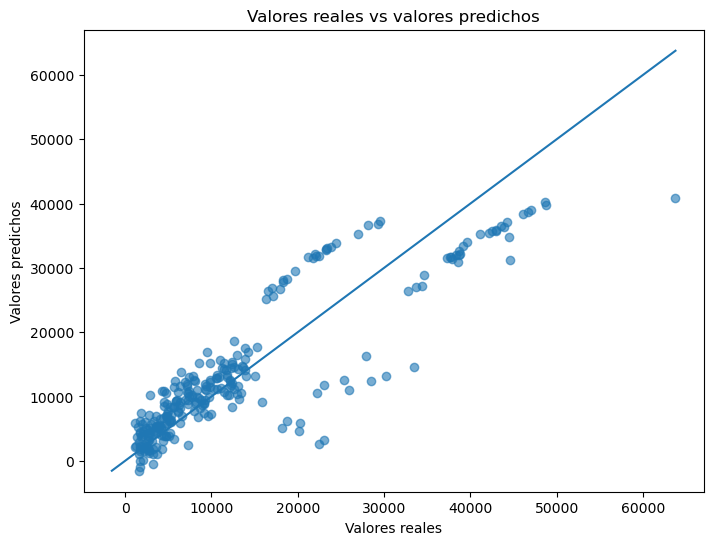

In [65]:
# ==========================================================
# COMPARACIÓN ENTRE VALORES REALES Y PREDICCIONES
# ==========================================================

# Comparo los valores reales de charges con los valores
# estimados por el modelo.

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Línea ideal: predicción = valor real
limite_minimo = min(
    y_test.min(),
    y_pred.min()
)

limite_maximo = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo]
)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs valores predichos")

plt.show()

# 10. Predicción con nuevos datos

En esta última etapa se utiliza el modelo entrenado para realizar una
predicción sobre una nueva observación.

El nuevo registro contiene las mismas variables predictoras utilizadas
durante el entrenamiento.

Gracias al Pipeline, el nuevo registro pasa automáticamente por el mismo
preprocesamiento, selección de atributos y modelo de Regresión Lineal antes
de generar la predicción.

In [67]:
# ==========================================================
# PREDICCIÓN DE UNA NUEVA OBSERVACIÓN
# ==========================================================

# Creo un nuevo registro con las mismas variables
# utilizadas durante el entrenamiento.

nuevo_paciente = pd.DataFrame({
    "age": [35],
    "sex": ["male"],
    "bmi": [28.5],
    "children": [1],
    "smoker": ["no"],
    "region": ["southwest"]
})

print("Nueva observación:")
display(nuevo_paciente)

Nueva observación:


,age,sex,bmi,children,smoker,region
0,35,male,28.5,1,no,southwest


In [68]:
# ==========================================================
# PREDICCIÓN DEL NUEVO REGISTRO
# ==========================================================

# El Pipeline aplica automáticamente el mismo
# preprocesamiento utilizado durante el entrenamiento.

prediccion_nueva = modelo.predict(
    nuevo_paciente
)

print(
    f"Gasto médico estimado: ${prediccion_nueva[0]:,.2f}"
)

Gasto médico estimado: $6,266.96


### 10.1 Interpretación de la predicción

El modelo recibe las características del nuevo registro y aplica
automáticamente las transformaciones definidas en el Pipeline.

Finalmente se obtiene una estimación del gasto médico (`charges`).

El valor obtenido corresponde a una predicción realizada por el modelo y no
a un valor real previamente registrado en el conjunto de datos.

# Conclusiones

- Se logró aplicar el proceso de preparación y análisis de datos para construir un modelo de Regresión Lineal Múltiple orientado a predecir los gastos médicos (`charges`).

- El análisis exploratorio permitió conocer la estructura y características del conjunto de datos, además de identificar valores atípicos que podían afectar el comportamiento del modelo.

- La preparación de las variables permitió trabajar correctamente con los diferentes tipos de datos. Las variables numéricas fueron estandarizadas mediante `StandardScaler`, mientras que las variables categóricas fueron transformadas utilizando `OneHotEncoder`.

- La utilización de `SelectKBest` junto con `f_regression` permitió seleccionar los atributos con mayor relación estadística con la variable objetivo, reduciendo las características utilizadas por el modelo.

- La división de los datos en entrenamiento y prueba, junto con la validación cruzada de 5 particiones, permitió comprobar el comportamiento del modelo utilizando diferentes subconjuntos de los datos.

- Finalmente, mediante las métricas MAE, MSE, RMSE, MAPE y R² se pudo evaluar el desempeño de la Regresión Lineal y realizar predicciones sobre nuevos datos. El uso de un Pipeline permitió integrar las diferentes etapas del proceso de Machine Learning de una manera organizada.